**Module 6**

---

**Problem 4**

In [56]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from matplotlib.colors import ListedColormap
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, roc_auc_score, auc, accuracy_score
)

import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'font.size': 14, 'figure.figsize': (8, 6)})
RNG = np.random.default_rng(42)

import time

import torch
# print(torch.__version__)
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

# set torch seed for reproducibility
torch.manual_seed(42)

# use GPU if available (not required)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")


Using device: cpu


## Background

You have been given data from a 2D Ising model simulation. Each sample is a 10x10 grid of spins ($\pm 1$), flattened to a 100-dimensional vector. The samples are labeled by phase:

- **Class 0**: Ordered (ferromagnetic) — spins are mostly aligned (low temperature)
- **Class 1**: Disordered (paramagnetic) — spins are randomized (high temperature)

Your goal is to classify spin configurations by phase using the tools from Module 4-6.

### Load the data

Split the data into train/test sets (70/30).

In [27]:
data = np.load('ising_data.npz')
X_ising = data['X']   # shape (N, 100) — flattened 10x10 spin configurations
y_ising = data['y']   # shape (N,) — 0 = ordered, 1 = disordered
T_ising = data['T']   # shape (N,) — temperature (for reference, not used in classification)

print(f'Samples: {X_ising.shape[0]}, Features: {X_ising.shape[1]}')
print(f'Ordered: {(y_ising==0).sum()}, Disordered: {(y_ising==1).sum()}')

# Train/test split
X_tr, X_te, y_tr, y_te = train_test_split(
    X_ising, y_ising, test_size=0.3, random_state=0, stratify=y_ising
)


Samples: 800, Features: 100
Ordered: 400, Disordered: 400


### Take a look at some configurations

Each row of `X_ising` is a flattened 10x10 grid. You can reshape and plot them as images.

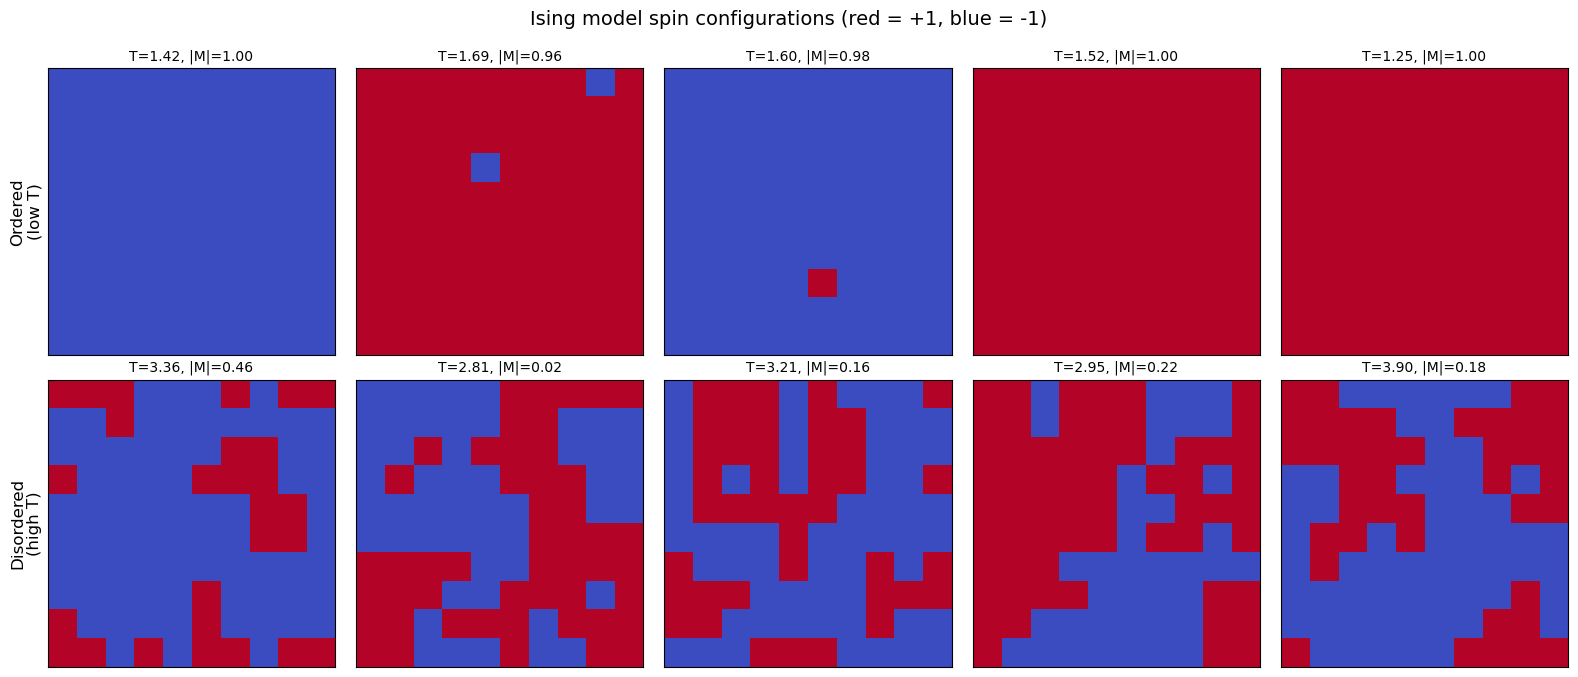

In [28]:
fig, axes = plt.subplots(2, 5, figsize=(16, 7))

ordered_idx = np.where(y_ising == 0)[0][:5]
for i, idx in enumerate(ordered_idx):
    axes[0, i].imshow(X_ising[idx].reshape(10, 10), cmap='coolwarm', vmin=-1, vmax=1)
    M = np.abs(X_ising[idx].mean())
    axes[0, i].set_title(f'T={T_ising[idx]:.2f}, |M|={M:.2f}', fontsize=10)
    axes[0, i].set_xticks([]); axes[0, i].set_yticks([])
axes[0, 0].set_ylabel('Ordered\n(low T)', fontsize=12)

disordered_idx = np.where(y_ising == 1)[0][:5]
for i, idx in enumerate(disordered_idx):
    axes[1, i].imshow(X_ising[idx].reshape(10, 10), cmap='coolwarm', vmin=-1, vmax=1)
    M = np.abs(X_ising[idx].mean())
    axes[1, i].set_title(f'T={T_ising[idx]:.2f}, |M|={M:.2f}', fontsize=10)
    axes[1, i].set_xticks([]); axes[1, i].set_yticks([])
axes[1, 0].set_ylabel('Disordered\n(high T)', fontsize=12)

fig.suptitle('Ising model spin configurations (red = +1, blue = -1)', fontsize=14)
plt.tight_layout()
plt.show()


---
## Logistic Regression

Fit a `LogisticRegression` classifier and report the test accuracy, AUC and training time.


In [29]:
lr = LogisticRegression(max_iter=1000)

start = time.time()
lr.fit(X_tr, y_tr) # Fit the model on the training data
end = time.time()
t_train_lr = end - start


In [30]:
y_pred = lr.predict(X_te)
acc_lr = accuracy_score(y_te, y_pred)
print(f"Test Accuracy: {acc_lr*100:.2f}%")
print("Training time (s):", t_train_lr)


Test Accuracy: 66.25%
Training time (s): 0.026097774505615234


---
## k-Nearest Neighbors (kNN)

**Idea:** Instead of learning a global boundary, classify each point by looking at its $k$ closest neighbors in the training set and taking a majority vote.

- **No assumptions** about the shape of the boundary
- Boundary adapts to the local structure of the data
- Tradeoff: $k$ is a hyperparameter
  - Small $k$: flexible boundary, may overfit
  - Large $k$: smoother boundary, may underfit

### How KNN makes predictions

For a new test point $\mathbf{x}$:
1. Find the $k$ training points closest to $\mathbf{x}$ (using Euclidean distance)
2. Count how many of those $k$ neighbors belong to each class
3. The predicted **probability** is the fraction of neighbors in each class:

$P(y = 1 \mid \mathbf{x}) = \frac{\text{number of class-1 neighbors among } k}{k}$

For example, with $k = 7$: if 5 neighbors are signal and 2 are background, then $P(\text{signal}) = 5/7 \approx 0.71$.

The default decision rule is: predict class 1 if $P > 0.5$, i.e., majority vote. But just like logistic regression, we can **sweep a threshold** on this probability to generate a ROC curve. The parameter being varied in the ROC is the decision threshold $\tau$, not $k$.

One subtlety: since probabilities are ratios of integers out of $k$, they are **quantized** — with $k = 7$ the only possible values are $0/7, 1/7, \ldots, 7/7$. This means the ROC curve will have a staircase shape rather than being perfectly smooth. (You would see this clearly with a smaller test set.)

Note also that KNN has **no training step** in the usual sense — it simply stores the training data and does all the work at prediction time. This makes it conceptually simple but computationally expensive for large datasets.

In [31]:
k = 5
knn = KNeighborsClassifier(n_neighbors=k)

start = time.time()
knn.fit(X_tr, y_tr)
end = time.time()
t_train_knn = end - start


---
## Decision tree

### The full algorithm

```
function BuildTree(data, labels):
    if stopping condition met:
        return LeafNode(majority class)
    
    for each feature j:
        for each threshold t:
            compute weighted Gini of the two subsets from splitting on (j, t)
    
    pick the (j*, t*) with the lowest weighted Gini
    split data into left (feature j* ≤ t*) and right (feature j* > t*)
    
    left_subtree  = BuildTree(left_data,  left_labels)
    right_subtree = BuildTree(right_data, right_labels)
    return Node(feature=j*, threshold=t*, left=left_subtree, right=right_subtree)
```

The stopping conditions can be: maximum depth reached, minimum samples per leaf, node is already pure, etc.


In [32]:
# Single tree (tuned depth)
d = 5
tree = DecisionTreeClassifier(max_depth=d, random_state=0)

start = time.time()
tree.fit(X_tr, y_tr)
end = time.time()
t_train_tree = end - start


Decision tree (depth=5)
Test Accuracy: 90.42%
Test AUC: 91.14%
Training time (s): 0.006229877471923828


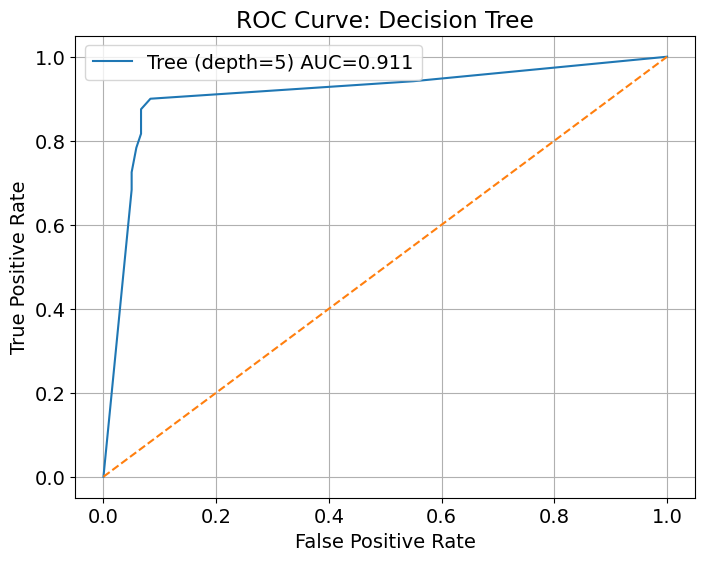

In [33]:
y_pred = tree.predict(X_te)
acc_tree = accuracy_score(y_te, y_pred)
y_prob = tree.predict_proba(X_te)[:, 1]
fpr_tree, tpr_tree, _ = roc_curve(y_te, y_prob)
auc_tree = auc(fpr_tree, tpr_tree)

label = f'depth={d}' if d is not None else 'no limit'
print(f"Decision tree ({label})")
print(f"Test Accuracy: {acc_tree*100:.2f}%")
print(f"Test AUC: {auc_tree*100:.2f}%")
print("Training time (s):", t_train_tree)

plt.plot(fpr_tree, tpr_tree, label=f"Tree ({label}) AUC={auc_tree:.3f}")
plt.plot([0, 1], [0, 1], '--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve: Decision Tree")
plt.legend()
plt.grid()
plt.show()


---
## Random forest

In [34]:
# Random forest
rf = RandomForestClassifier(n_estimators=200, random_state=0)

start = time.time()
rf.fit(X_tr, y_tr)
end = time.time()
t_train_rf = end - start


---
## Gradient boosting

Fit a `GradientBoostingClassifier` with 200 trees. Then use `staged_predict` to get the prediction at every boosting stage and compute the test accuracy at each stage.

`staged_predict` is a generator that yields the ensemble's prediction after each tree is added — so you get the full learning curve from a single fit.

In [35]:
# Fit 
gb = GradientBoostingClassifier(n_estimators=200, max_depth=3, learning_rate=0.1, random_state=0)

start = time.time()
gb.fit(X_tr, y_tr)
end = time.time()
t_train_gb = end - start


Test Accuracy: 97.92%
Training time (s): 0.2592489719390869


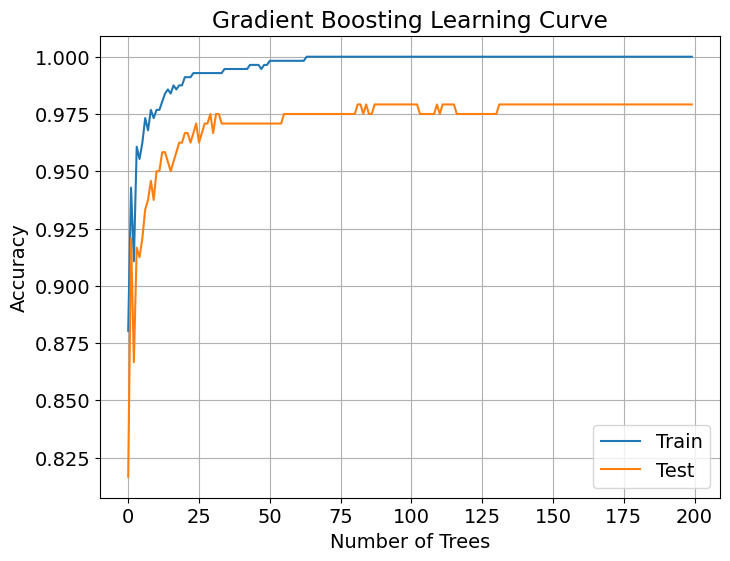

In [36]:
y_pred = gb.predict(X_te)
acc_gb = accuracy_score(y_te, y_pred)
print(f"Test Accuracy: {acc_gb*100:.2f}%")
print("Training time (s):", t_train_gb)

# Compute test accuracy at each stage
gb_test_accs = []
for y_pred in gb.staged_predict(X_te):
    gb_test_accs.append(accuracy_score(y_te, y_pred))
    
# Do the same for the training set 
gb_train_accs = []
for y_pred in gb.staged_predict(X_tr):
    gb_train_accs.append(accuracy_score(y_tr, y_pred))

plt.plot(gb_train_accs, label='Train')
plt.plot(gb_test_accs, label='Test')

plt.xlabel('Number of Trees')
plt.ylabel('Accuracy')
plt.title('Gradient Boosting Learning Curve')
plt.legend()
plt.grid()
plt.show()


---
## Neural network

### From numpy to PyTorch tensors

The first step is converting our numpy arrays to PyTorch tensors. A `DataLoader` handles batching and shuffling automatically.

In [37]:
# Convert to PyTorch tensors
X_tr_t = torch.tensor(X_tr, dtype=torch.float32).to(device)
y_tr_t = torch.tensor(y_tr, dtype=torch.float32).to(device)
X_te_t = torch.tensor(X_te, dtype=torch.float32).to(device)
y_te_t = torch.tensor(y_te, dtype=torch.float32).to(device)

# Create DataLoader for mini-batch training
train_dataset = TensorDataset(X_tr_t, y_tr_t)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_dataset = TensorDataset(X_te_t, y_te_t)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=True)

print(f"Tensor shapes: X_train {X_tr_t.shape}, y_train {y_tr_t.shape}")


Tensor shapes: X_train torch.Size([560, 100]), y_train torch.Size([560])


### Define the network — Multiple Hidden Layers

In PyTorch, we define a network as a class that inherits from `nn.Module`. We only need to write the forward pass — PyTorch computes the backward pass automatically.

**A flexible network builder**

Does adding more layers help?

Deeper networks can represent more complex functions, but they are also harder to train and more prone to overfitting. This is the bias-variance tradeoff again.

Let's write a general network class that accepts any list of hidden layer sizes.v

In [38]:
class FlexNet(nn.Module):
    """
    Flexible feedforward network.
    
    hidden_sizes: list of ints, e.g. [32, 16] for 2 hidden layers
    activation: 'sigmoid', 'relu', or 'tanh'
    """
    def __init__(self, input_dim, hidden_sizes, activation='relu'): # num_classes,
        super().__init__()
        
        act_map = {'sigmoid': nn.Sigmoid, 'relu': nn.ReLU, 'tanh': nn.Tanh}
        act_fn = act_map[activation]
        
        layers = []
        prev_dim = input_dim
        for h in hidden_sizes:
            layers.append(nn.Linear(prev_dim, h))
            layers.append(act_fn())
            prev_dim = h
        # for 1 class (1 neuron)
        layers.append(nn.Linear(prev_dim, 1))
        layers.append(nn.Sigmoid())  # output probability
        # output layer for multi-class
        # layers.append(nn.Linear(prev_dim, num_classes)) # output layer for multi-class
        
        self.network = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.network(x).squeeze(-1)
    # def forward(self, x):
    #     # Flatten input if needed
    #     x = x.view(x.size(0), -1)
    #     return self.network(x)  # raw logits


# Example: 2-layer network
net_deep = FlexNet(100, [64, 32], activation='relu').to(device)
print(net_deep)
n_params = sum(p.numel() for p in net_deep.parameters())
print(f"\nTotal parameters: {n_params:,}")


FlexNet(
  (network): Sequential(
    (0): Linear(in_features=100, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=1, bias=True)
    (5): Sigmoid()
  )
)

Total parameters: 8,577


### The training loop

The PyTorch training loop has a simple rhythm:

```
for each epoch:
    for each batch:
        1. Forward pass  → compute predictions
        2. Compute loss
        3. Backward pass → compute gradients (automatic!)
        4. Update parameters
        5. Zero gradients for next iteration
```

Notice steps 3 and 5 — these are the parts that PyTorch automates.

In [39]:
def train_pytorch(model, train_loader, test_loader, lr=0.01, n_epochs=100, verbose=True):
    """
    Train a PyTorch model and track train/test loss.

    Arguments:
    - model: PyTorch nn.Module
    - train_loader: DataLoader for training set
    - test_loader: DataLoader for test set
    - lr: learning rate
    - n_epochs: number of epochs
    - verbose: print progress every 1 epoch
    """
    # Loss & optimizer
    criterion = nn.BCELoss()  # binary cross-entropy
    # criterion = nn.CrossEntropyLoss()  # combines softmax + log loss, works directly with raw logits
    optimizer = optim.Adam(model.parameters(), lr=lr)

    # load test set
    X_test_list = []
    y_test_list = []     
    for X_batch, y_batch in test_loader:
        X_test_list.append(X_batch)
        y_test_list.append(y_batch)
    X_test = torch.cat(X_test_list, dim=0)
    y_test = torch.cat(y_test_list, dim=0)
    
    train_losses = []
    test_losses = []
    accuracies = []

    # Training loop
    for epoch in range(n_epochs):
        # training
        model.train()
        epoch_loss = 0.0
        n_train_batches = 0

        for X_batch, y_batch in train_loader:
            # X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            # X_batch = X_batch.view(X_batch.size(0), -1)  # flatten input
            
            # forward
            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)
            
            # backward (automatic!)
            optimizer.zero_grad()
            loss.backward()
            
            # update
            optimizer.step()
            
            epoch_loss += loss.item() # average loss in 1 batch, nn.CrossEntropyLoss by default returns mean over the batch
            n_train_batches += 1
        
        train_losses.append(epoch_loss / n_train_batches)

        # evaluate on test set
        model.eval()
        with torch.no_grad():
            y_pred_test = model(X_test)
            
            test_loss = criterion(y_pred_test, y_test).item()
            test_losses.append(test_loss)

            acc = ((y_pred_test > 0.5).float() == y_test).float().mean().item()
            # Accuracy for multi-class
            # _, predicted = torch.max(y_pred_test, 1)
            # acc = (predicted == y_test).float().mean().item()
            accuracies.append(acc)

        if verbose  and epoch % (n_epochs//10) == 0:
            print(f"  epoch {epoch:4d}  train_loss={train_losses[-1]:.4f}  "
                  f"test_loss={test_losses[-1]:.4f}  test_acc={accuracies[-1]:.2%}")
    
    # ======================
    # FINAL ROC DATA ONLY
    # ======================
    model.eval()
    with torch.no_grad():
        y_pred_test = model(X_test)
    all_probs = y_pred_test.detach().cpu().numpy()
    all_targets = y_test.detach().cpu().numpy()
        
    return train_losses, test_losses, accuracies, all_targets, all_probs


FlexNet(
  (network): Sequential(
    (0): Linear(in_features=100, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=1, bias=True)
    (5): Sigmoid()
  )
)
Training with PyTorch...
  epoch    0  train_loss=0.6400  test_loss=0.5768  test_acc=59.17%
  epoch   15  train_loss=0.0320  test_loss=0.1473  test_acc=96.67%
  epoch   30  train_loss=0.0051  test_loss=0.1661  test_acc=97.50%
  epoch   45  train_loss=0.0017  test_loss=0.1810  test_acc=97.92%
  epoch   60  train_loss=0.0008  test_loss=0.1921  test_acc=97.92%
  epoch   75  train_loss=0.0004  test_loss=0.2009  test_acc=97.50%
  epoch   90  train_loss=0.0003  test_loss=0.2081  test_acc=97.50%
  epoch  105  train_loss=0.0002  test_loss=0.2145  test_acc=97.50%
  epoch  120  train_loss=0.0001  test_loss=0.2205  test_acc=97.50%
  epoch  135  train_loss=0.0001  test_loss=0.2253  test_acc=97.50%


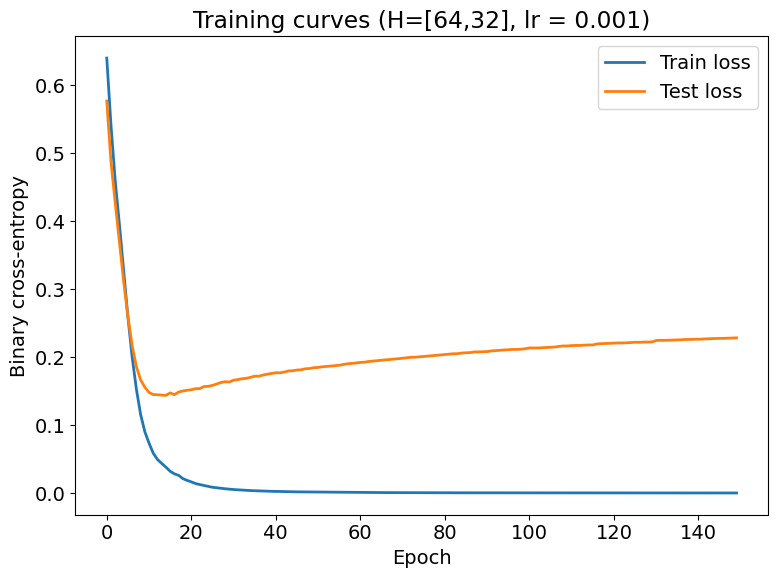

In [42]:
# Hyperparameters
input_size = 10*10
hidden_size = [64, 32]
num_classes = 1
batch_size = 64
learning_rate = 0.001
num_epochs = 150

net_deep = FlexNet(input_size, hidden_size, activation='relu').to(device)
print(net_deep)

print("Training with PyTorch...")
start = time.time()
train_losses, test_losses, accuracies, all_targets, all_probs = train_pytorch(
    model=net_deep, 
    train_loader=train_loader, 
    test_loader=test_loader,
    lr=learning_rate,
    n_epochs=num_epochs
)
end = time.time()
t_train_NN = end - start

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(train_losses, label='Train loss', lw=2)
ax.plot(test_losses, label='Test loss', lw=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('Binary cross-entropy')
ax.set_title('Training curves (H=[64,32], lr = 0.001)')
ax.legend()
plt.tight_layout()
plt.show()


                                        Model   Test Acc   AUC        Training time (s)
---------------------------------------------------------------------------------------
                          Logistic regression   66.25%     48.60%     0.0261
                   k-nearest neighbours (k=5)   81.67%     89.34%     0.0019
                          Decision tree (d=5)   90.42%     91.14%     0.0062
                    Random forest (200 trees)   98.33%     97.65%     0.1546
   Gradient boosting (200 trees, d=3, lr=0.1)   97.92%     98.14%     0.2592
 Neural network (H=[64,32], ReLU, 150 epochs)   97.50%     97.01%     0.6264


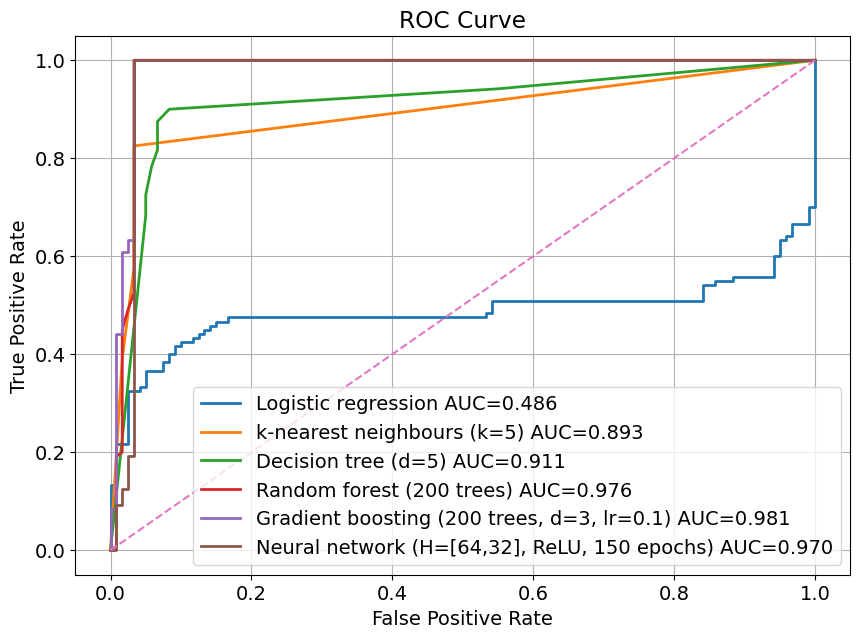

In [43]:
classifiers = {}
classifiers['Logistic regression'] = {
    'model': lr,
    'train_time': t_train_lr
}
classifiers['k-nearest neighbours (k=5)'] = {
    'model': knn,
    'train_time': t_train_knn
}
classifiers['Decision tree (d=5)'] = {
    'model': tree,
    'train_time': t_train_tree
}
classifiers['Random forest (200 trees)'] = {
    'model': rf,
    'train_time': t_train_rf
}
classifiers['Gradient boosting (200 trees, d=3, lr=0.1)'] = {
    'model': gb,
    'train_time': t_train_gb
}


# Report results
fig, ax = plt.subplots(figsize=(10, 7))

print(f'{"Model":>45s}   Test Acc   AUC        Training time (s)')
print('-' * 87)
for name, info in classifiers.items():
    clf = info['model']
    t_train = info['train_time']
    
    y_pred = clf.predict(X_te)
    acc = accuracy_score(y_te, y_pred)
    y_prob = clf.predict_proba(X_te)[:, 1]
    fpr, tpr, _ = roc_curve(y_te, y_prob)
    auc_val = auc(fpr, tpr)
    
    print(f'{name:>45s}   {acc:.2%}     {auc_val:.2%}     {t_train:.4f}')
    
    ax.plot(fpr, tpr, lw=2, label=f'{name} AUC={auc_val:.3f}')

# Neural network
acc_NN = accuracies[-1]
fpr_NN, tpr_NN, _ = roc_curve(all_targets, all_probs)
auc_NN = auc(fpr_NN, tpr_NN)
print(f'{"Neural network (H=[64,32], ReLU, 150 epochs)":>45s}   {acc_NN:.2%}     {auc_NN:.2%}     {t_train_NN:.4f}')
plt.plot(fpr_NN, tpr_NN, lw=2, label=f"Neural network (H=[64,32], ReLU, 150 epochs) AUC={auc_NN:.3f}")

plt.plot([0, 1], [0, 1], '--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid()
plt.show()


## Engineered features

Add three hand-crafted features to the raw spin data:

1. Mean magnetization
$$M = \frac{1}{N_{\text{spins}}} \sum_i s_i$$
This is just `X_ising.mean(axis=1)`. Plot a histogram of $M$, colored by the true phase label (ordered vs disordered). Use `alpha=0.5` so you can see both distributions.

2. Absolute magnetization: $|M|$
3. Nearest-neighbor energy
$$E_{nn} = \frac{-1}{N_{\text{bonds}}} \sum_{⟨i,j⟩} s_i s_j$$


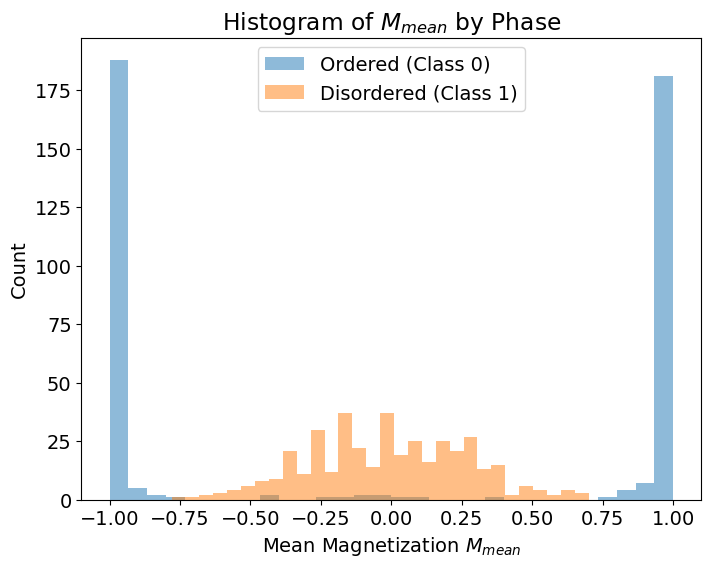

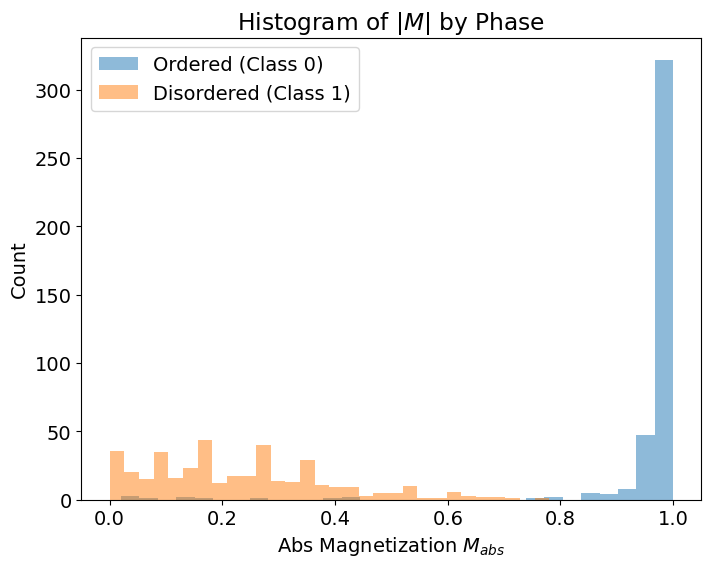

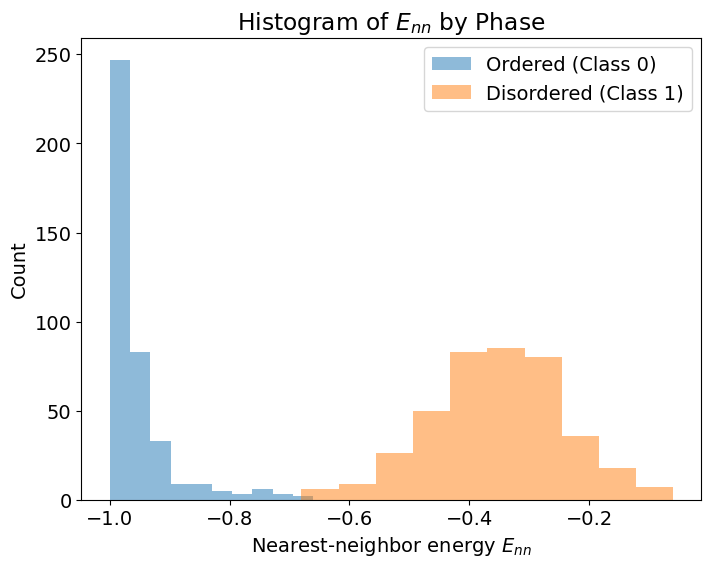

In [52]:
# Mean magnetization
M_mean = X_ising.mean(axis=1)
M_ordered = M_mean[y_ising == 0]
M_disordered = M_mean[y_ising == 1]

plt.hist(M_ordered, bins=30, alpha=0.5, label="Ordered (Class 0)")
plt.hist(M_disordered, bins=30, alpha=0.5, label="Disordered (Class 1)") # alpha is the transparency
plt.xlabel("Mean Magnetization $M_{mean}$")
plt.ylabel("Count")
plt.title("Histogram of $M_{mean}$ by Phase")
plt.legend()

plt.show()

# Abs magnetization
M_abs = np.abs(M_mean)
M_ordered = M_abs[y_ising == 0]
M_disordered = M_abs[y_ising == 1]

plt.hist(M_ordered, bins=30, alpha=0.5, label="Ordered (Class 0)")
plt.hist(M_disordered, bins=30, alpha=0.5, label="Disordered (Class 1)") # alpha is the transparency
plt.xlabel("Abs Magnetization $M_{abs}$")
plt.ylabel("Count")
plt.title("Histogram of $|M|$ by Phase")
plt.legend()

plt.show()

# Nearest-neighbor energy
N = X_ising.shape[0]
L = 10
X_lattices = X_ising.reshape(N, L, L)
# print(X_lattices[1])

# assume periodic boundary conditions
def nn_energy(spins):
    L = spins.shape[0]
    E = 0.0
    for i in range(L):
        for j in range(L):
            # right neighbor
            E -= spins[i, j] * spins[i, (j + 1) % L]
            # down neighbor
            E -= spins[i, j] * spins[(i + 1) % L, j]
    return E/(2*L*L)

E_nn = np.array([nn_energy(x) for x in X_lattices])
E_ordered = E_nn[y_ising == 0]
E_disordered = E_nn[y_ising == 1]

plt.hist(E_ordered, bins=10, alpha=0.5, label="Ordered (Class 0)")
plt.hist(E_disordered, bins=10, alpha=0.5, label="Disordered (Class 1)") # alpha is the transparency
plt.xlabel("Nearest-neighbor energy $E_{nn}$")
plt.ylabel("Count")
plt.title("Histogram of $E_{nn}$ by Phase")
plt.legend()

plt.show()


In [53]:
M_mean = X_ising.mean(axis=1)
M_abs = np.abs(M_mean)
E_nn = np.array([nn_energy(x) for x in X_lattices])

X_feat = np.column_stack([X_ising, M_mean, M_abs, E_nn])
X_feat.shape
print(f'Samples: {X_feat.shape[0]}, Features: {X_feat.shape[1]}')
print(f'Ordered: {(y_ising==0).sum()}, Disordered: {(y_ising==1).sum()}')

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_feat, y_ising, test_size=0.3, random_state=0, stratify=y_ising
)


Samples: 800, Features: 103
Ordered: 400, Disordered: 400


In [54]:
# log regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train) # Fit the model on the training data

y_pred = lr.predict(X_test)
acc_lr_feat = accuracy_score(y_test, y_pred)


# gradient boosting
gb = GradientBoostingClassifier(n_estimators=200, max_depth=3, learning_rate=0.1, random_state=0)
gb.fit(X_train, y_train)

y_pred = gb.predict(X_test)
acc_gb_feat = accuracy_score(y_test, y_pred)


print(f'{"Model":>45s}   Test Acc w/o Feat   Test Acc w/ Feat')
print('-' * 87)
print(f'{"Logistic regression":>45s}   {acc_lr:.2%}              {acc_lr_feat:.2%}')
print(f'{"Gradient boosting (200 trees, d=3, lr=0.1)":>45s}   {acc_gb:.2%}              {acc_gb_feat:.2%}')


                                        Model   Test Acc w/o Feat   Test Acc w/ Feat
---------------------------------------------------------------------------------------
                          Logistic regression   66.25%              97.50%
   Gradient boosting (200 trees, d=3, lr=0.1)   97.92%              99.17%


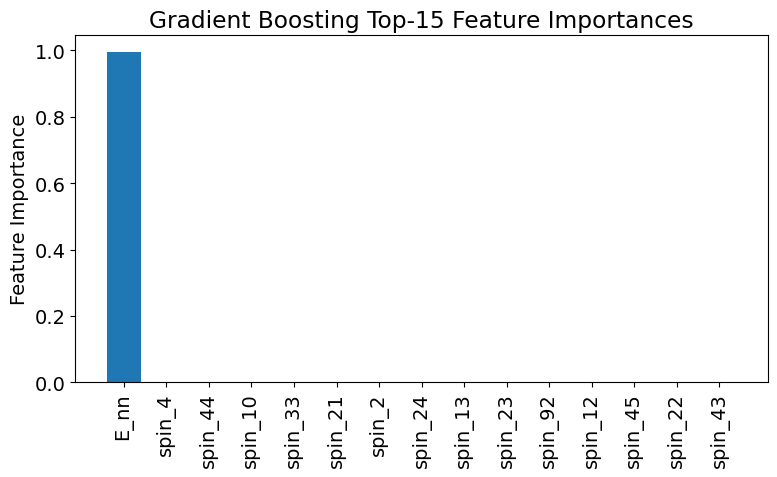

Importance of |M|:  2.3009005963990323e-08


In [55]:
importances = gb.feature_importances_

top_k = 15
idx = np.argsort(importances)[::-1][:top_k]

n_spin = X_ising.shape[1]   # 100

feature_names = [f"spin_{i}" for i in range(n_spin)] + ["M_mean", "|M|", "E_nn"]
# print(len(feature_names))
# print(X_feat.shape[1])

plt.figure(figsize=(8, 5))

plt.bar(range(top_k), importances[idx])
plt.xticks(range(top_k), [feature_names[i] for i in idx], rotation=90)

plt.ylabel("Feature Importance")
plt.title("Gradient Boosting Top-15 Feature Importances")
plt.tight_layout()
plt.show()

print('Importance of |M|: ',importances[-2])


It is shown that importance of $E_{nn}$ is almost 1 while the other importances (including that of $|M|$) tend to 0, so $|M|$ does not dominate. However, when trained without the feature $E_{nn}$, $|M|$ is important and actually dominates. 

## Discussion
- Which classifier performed best on raw spins? With engineered features?

    w/o features: Gradient boosting had the 2nd best training accuracy and best AUC.

    w/ features: Probably still gradient boosting.
- When is it worth engineering features by hand vs letting the model figure it out?

    It is worth engineering features by hand when we have some physical understanding of the model. Without any physical knowledge, we let the model figure it out.
- If you were analyzing data from a real experiment and had to choose one classifier as your default starting point, which would you choose and why?

  Depend on the experiment and what data I get, most likely I would use a decision tree coz the logic is readable and it can classify non-linear boundary.
